In [1]:
from typing import List, Dict, Union
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from siglab_py.util.simple_math import bucket_series, bucketize_val

##### Load trade file

In [2]:
trade_file = r"D:\dev\siglab\historical_trades_OKX_XAG_20260601.csv"
pd_historical_trades = pd.read_csv(trade_file)
pd_historical_trades.drop(pd_historical_trades.columns[pd_historical_trades.columns.str.contains('unnamed',case = False)],axis = 1, inplace = True)
pd_historical_trades.drop(['info'],axis = 1, inplace = True)
pd_historical_trades['timestamp_ms'] = pd_historical_trades['timestamp_ms'].astype('Int64')
pd_historical_trades

,timestamp_ms,datetime,symbol,id,order,type,takerOrMaker,side,price,amount_base_ccy,...,year,month,day,hour,minute,dayofweek,week_of_month,apac_trading_hr,emea_trading_hr,amer_trading_hr
0,1780306580460,2026-06-01 17:36:20,BTC/USDT:USDT,2638535424,NaN,NaN,NaN,buy,72912.0,0.02,...,2026,6,1,17,36,0,2,False,True,True
1,1780306580460,2026-06-01 17:36:20,BTC/USDT:USDT,2638535422,NaN,NaN,NaN,buy,72912.0,0.08,...,2026,6,1,17,36,0,2,False,True,True
2,1780306580460,2026-06-01 17:36:20,BTC/USDT:USDT,2638535421,NaN,NaN,NaN,buy,72912.0,0.08,...,2026,6,1,17,36,0,2,False,True,True
3,1780306580460,2026-06-01 17:36:20,BTC/USDT:USDT,2638535423,NaN,NaN,NaN,buy,72912.0,0.97,...,2026,6,1,17,36,0,2,False,True,True
4,1780306580460,2026-06-01 17:36:20,BTC/USDT:USDT,2638535425,NaN,NaN,NaN,buy,72912.0,0.01,...,2026,6,1,17,36,0,2,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400019,1780329572309,2026-06-01 23:59:32,BTC/USDT:USDT,2639993309,NaN,NaN,NaN,sell,71094.3,0.57,...,2026,6,1,23,59,0,2,False,True,True
400020,1780329572309,2026-06-01 23:59:32,BTC/USDT:USDT,2639993308,NaN,NaN,NaN,sell,71094.3,0.02,...,2026,6,1,23,59,0,2,False,True,True
400021,1780329572309,2026-06-01 23:59:32,BTC/USDT:USDT,2639993307,NaN,NaN,NaN,sell,71094.3,0.01,...,2026,6,1,23,59,0,2,False,True,True
400022,1780329572309,2026-06-01 23:59:32,BTC/USDT:USDT,2639993306,NaN,NaN,NaN,sell,71094.3,0.42,...,2026,6,1,23,59,0,2,False,True,True


In [3]:
min_datetime = pd_historical_trades['datetime'].min()
max_datetime = pd_historical_trades['datetime'].max()
amount_quote_ccy_min = pd_historical_trades['amount_quote_ccy'].min()
amount_quote_ccy_max = pd_historical_trades['amount_quote_ccy'].max()
amount_quote_ccy_mean = pd_historical_trades['amount_quote_ccy'].mean()
amount_quote_ccy_sum = pd_historical_trades['amount_quote_ccy'].sum()

summary = {
    "min_datetime" : min_datetime,
    "max_datetime" : max_datetime,
    "amount_quote_ccy_min": f"{amount_quote_ccy_min:,.0f}",
    "amount_quote_ccy_max": f"{amount_quote_ccy_max:,.0f}",
    "amount_quote_ccy_mean": f"{amount_quote_ccy_mean:,.2f}",
    "amount_quote_ccy_sum": f"{amount_quote_ccy_sum:,.0f}"
}

summary


{'min_datetime': '2026-06-01 17:36:20',
 'max_datetime': '2026-06-01 23:59:32',
 'amount_quote_ccy_min': '711',
 'amount_quote_ccy_max': '624,244,176',
 'amount_quote_ccy_mean': '235,026.89',
 'amount_quote_ccy_sum': '94,016,397,145'}

##### Bucketize amount_quote_ccy column

In [4]:
MIN_AMOUNT_QUOTE_CCY = 1_000_000
MAX_AMOUNT_QUOTE_CCY = 10_000_000

In [5]:
_pd_historical_trades = pd_historical_trades[(pd_historical_trades.amount_quote_ccy>=MIN_AMOUNT_QUOTE_CCY) & (pd_historical_trades.amount_quote_ccy<=MAX_AMOUNT_QUOTE_CCY)]

In [6]:
level_granularity = 0.1

amount_quote_values = _pd_historical_trades['amount_quote_ccy'].tolist()

buckets : Dict[
            str, 
            Dict[str,Union[float, List[float]]]
        ] = bucket_series(
                                                values = amount_quote_values,
                                                outlier_threshold_percent = 10,
                                                level_granularity=level_granularity
                                            )
        
pd_historical_trades['amount_quote_ccy_bucket'] = pd_historical_trades['amount_quote_ccy'].apply(
    lambda x: bucketize_val(x, buckets)
)

In [7]:
selected_columns = ['symbol', 'datetime', 'timestamp_ms', 'id', 'side', 'price', 
                   'amount_base_ccy', 'amount_quote_ccy', 'amount_quote_ccy_bucket', 
                   'datetime_utc', 'year', 'month', 'day', 'hour', 'minute', 
                   'dayofweek', 'week_of_month', 'apac_trading_hr', 'emea_trading_hr', 
                   'amer_trading_hr']
pd_historical_trades = pd_historical_trades[selected_columns]

styled = pd_historical_trades[:10].style.format({
    'amount_base_ccy': '{:,.2f}',
    'amount_quote_ccy': '{:,.2f}'
})
styled

,symbol,datetime,timestamp_ms,id,side,price,amount_base_ccy,amount_quote_ccy,amount_quote_ccy_bucket,datetime_utc,year,month,day,hour,minute,dayofweek,week_of_month,apac_trading_hr,emea_trading_hr,amer_trading_hr
0,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580460,2638535424,buy,72912.000000,0.02,"1,458.24",< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
1,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580460,2638535422,buy,72912.000000,0.08,"5,832.96",< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
2,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580460,2638535421,buy,72912.000000,0.08,"5,832.96",< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
3,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580460,2638535423,buy,72912.000000,0.97,"70,724.64",< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
4,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580460,2638535425,buy,72912.000000,0.01,729.12,< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
5,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580460,2638535426,buy,72912.000000,1.99,"145,094.88",< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
6,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580479,2638535433,buy,72912.000000,0.12,"8,749.44",< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
7,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580479,2638535432,buy,72912.000000,0.06,"4,374.72",< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
8,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580479,2638535431,buy,72912.000000,0.06,"4,374.72",< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True
9,BTC/USDT:USDT,2026-06-01 17:36:20,1780306580479,2638535429,buy,72912.000000,0.01,729.12,< 1000000,2026-06-01 09:36:20+00:00,2026,6,1,17,36,0,2,False,True,True


In [8]:
grouped = pd_historical_trades.groupby(['amount_quote_ccy_bucket']).agg(
    simple_count=('id', 'size'),
    sum_amount_quote_ccy=('amount_quote_ccy', 'sum'),
).reset_index()
grouped['sum_amount_quote_ccy'] = grouped['sum_amount_quote_ccy'].round(0)

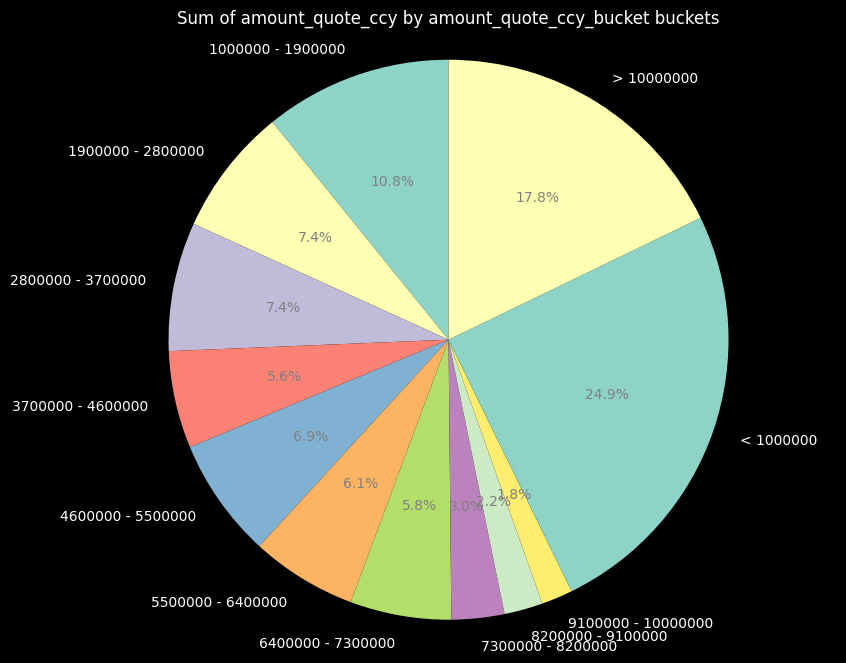

In [9]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(grouped['sum_amount_quote_ccy'], 
                                  labels=grouped['amount_quote_ccy_bucket'], 
                                  autopct='%1.1f%%', 
                                  startangle=90)
for autotext in autotexts:
    autotext.set_color('gray')
ax.set_title('Sum of amount_quote_ccy by amount_quote_ccy_bucket buckets')
ax.axis('equal')
plt.show()

In [10]:
grouped['sum_amount_quote_ccy'] = grouped['sum_amount_quote_ccy'].round(0).astype(int).apply(lambda x: f'{x:,}')
grouped

,amount_quote_ccy_bucket,simple_count,sum_amount_quote_ccy
0,1000000 - 1900000,7369,"10,181,406,377"
1,1900000 - 2800000,3064,"6,941,318,870"
2,2800000 - 3700000,2145,"6,993,214,970"
3,3700000 - 4600000,1271,"5,287,160,550"
4,4600000 - 5500000,1282,"6,506,010,038"
5,5500000 - 6400000,969,"5,755,692,571"
6,6400000 - 7300000,803,"5,494,754,840"
7,7300000 - 8200000,373,"2,865,604,398"
8,8200000 - 9100000,243,"2,095,621,573"
9,9100000 - 10000000,178,"1,698,575,661"


##### Histogram on amount_quote_ccy, over focused notional ranges

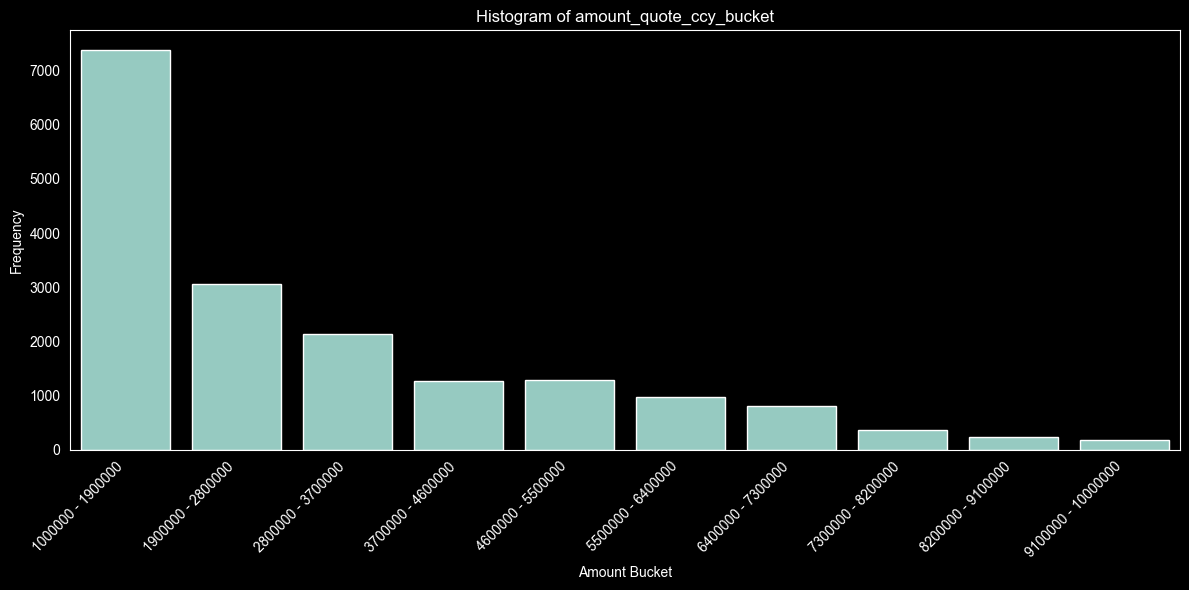

In [11]:
_pd_historical_trades = pd_historical_trades[(pd_historical_trades.amount_quote_ccy>=MIN_AMOUNT_QUOTE_CCY) & (pd_historical_trades.amount_quote_ccy<=MAX_AMOUNT_QUOTE_CCY)]

sns.set_style('dark')
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

bucket_order = sorted(_pd_historical_trades['amount_quote_ccy_bucket'].unique(),
                      key=lambda x: float(x.split(' - ')[0].replace('< ', '').replace('> ', '')))

sns.countplot(
    data=_pd_historical_trades,
    x='amount_quote_ccy_bucket',
    order=bucket_order,
    edgecolor='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')
plt.xlabel('Amount Bucket', color='white')
plt.ylabel('Frequency', color='white')
plt.title('Histogram of amount_quote_ccy_bucket', color='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
ax.grid(False)
plt.tight_layout()
plt.show()